# 05 – Conciliación maestra vs contraste (Corea, nivel nacional)
Regla del proyecto: **una fuente maestra por indicador**; las de contraste solo se comparan, nunca reemplazan.
Para cada par año–indicador se calcula `dif_pct = (contraste − maestra) / |maestra| × 100`, con la misma forma que `silver.conciliacion`.

**KPI (KR3):** % de pares año–indicador con |dif| ≤ tolerancia (3 %), meta **≥ 90 %**. Solo cuentan los pares **comparables por definición**; los que miden otra cosa (OECD dependencia 65+/20-64, PIB por ocupado) se reportan aparte.

In [1]:
import sys; from pathlib import Path; sys.path.insert(0, str(Path.cwd().parent))
import yaml
import pandas as pd
import matplotlib.pyplot as plt
from src.transform import lectura_bronze as lb
from src.quality import perfilamiento as pf

CFG = yaml.safe_load((Path.cwd().parent / "config" / "config.yaml").read_text(encoding="utf-8"))
TOL = CFG["calidad"]["tolerancia_conciliacion_pct"]
HIST = range(CFG["periodo_historico"]["inicio"], CFG["periodo_historico"]["fin"] + 1)
pd.set_option("display.float_format", "{:,.2f}".format)
print(f"Tolerancia: ±{TOL} % | histórico {HIST.start}-{HIST.stop - 1}")

Tolerancia: ±3.0 % | histórico 2000-2025


## 1. Series maestras (KOSIS)
- TFR y nacimientos: fila *Whole country* de las tablas si-do. EAPS: fila *Total*, niveles en **miles → personas**.
- Población: total (`계`) y agregados 0-14 / 15-64 / 65+ sumando quinquenales (se excluye el agregado `80세이상`). El mismo archivo trae 2000-2021 estimado y 2022-2072 proyección media: años ≤ 2025 → histórico, ≥ 2026 → proyección.
- Derivados calculados en el pipeline: dependencia de vejez (65+/15-64×100), índice de envejecimiento (65+/0-14×100) y proporción 65+.

In [2]:
def serie(df, indicador, grupo="TOTAL", factor=1):
    return pd.DataFrame({"cod_indicador": indicador, "grupo_edad": grupo,
                         "anio": df["anio"].values, "valor": df["valor"].values * factor})

vit, tfr, eaps = lb.kosis_vitales_sido(), lb.kosis_tfr_sido(), lb.kosis_eaps_sido()
vit, tfr, eaps = vit[vit.territorio == "Whole country"], tfr[tfr.territorio == "Whole country"], eaps[eaps.territorio == "Total"]
ITEMS_EAPS = {"Economically active population (Thousand Person)": ("POB_ACTIVA", 1000),
              "Employed persons (Thousand Person)": ("OCUPADOS", 1000),
              "Labor Force Participation rate (%)": ("TASA_PARTICIPACION", 1),
              "Unemployment rate (%)": ("TASA_DESEMPLEO", 1)}

# Población nacional por agregado de edad (quinquenales sin el agregado 80세이상)
pob = lb.kosis_poblacion_nacional().query("sexo == '전체' and edad != '80세이상'").copy()
pob["edad_min"] = pob["edad"].str.extract(r"^(\d+)", expand=False).astype(float)
quin = pob.dropna(subset=["edad_min"])
agr = pd.DataFrame({
    "TOTAL": pob[pob.edad == "계"].set_index("anio").valor,
    "0-14": quin[quin.edad_min < 15].groupby("anio").valor.sum(),
    "15-64": quin[quin.edad_min.between(15, 64)].groupby("anio").valor.sum(),
    "20-64": quin[quin.edad_min.between(20, 64)].groupby("anio").valor.sum(),
    "65+": quin[quin.edad_min >= 65].groupby("anio").valor.sum()})
print("Máx |suma 0-14 + 15-64 + 65+ − total|:", (agr[["0-14", "15-64", "65+"]].sum(axis=1) - agr["TOTAL"]).abs().max())
agr = agr.reset_index()

maestra = pd.concat(
    [serie(tfr[tfr["item"] == "Total Fertility Rate"], "TFR"),
     serie(vit[vit["item"] == "Live births(persons)"], "NACIMIENTOS")]
    + [serie(eaps[eaps["item"] == it], ind, factor=f) for it, (ind, f) in ITEMS_EAPS.items()]
    + [serie(agr.rename(columns={g: "valor"}), "POBLACION", g) for g in ["TOTAL", "0-14", "15-64", "65+"]]
    + [serie(agr.assign(valor=agr["65+"] / agr["15-64"] * 100), "DEPENDENCIA_VEJEZ"),
       serie(agr.assign(valor=agr["65+"] / agr["0-14"] * 100), "INDICE_ENVEJECIMIENTO"),
       serie(agr.assign(valor=agr["65+"] / agr["TOTAL"] * 100), "PROP_65MAS")], ignore_index=True).dropna()
maestra.groupby(["cod_indicador", "grupo_edad"]).anio.agg(["min", "max", "size"])

Máx |suma 0-14 + 15-64 + 65+ − total|: 0


min   max  size
cod_indicador         grupo_edad                  
DEPENDENCIA_VEJEZ     TOTAL       2000  2072    73
INDICE_ENVEJECIMIENTO TOTAL       2000  2072    73
NACIMIENTOS           TOTAL       2000  2025    26
OCUPADOS              TOTAL       2000  2025    26
POBLACION             0-14        2000  2072    73
                      15-64       2000  2072    73
                      65+         2000  2072    73
                      TOTAL       2000  2072    73
POB_ACTIVA            TOTAL       2000  2025    26
PROP_65MAS            TOTAL       2000  2072    73
TASA_DESEMPLEO        TOTAL       2000  2025    26
TASA_PARTICIPACION    TOTAL       2000  2025    26
TFR                   TOTAL       2000  2025    26

## 2. Series de contraste
Filtros obligatorios (config): OECD fecundidad a nivel país (`TERRITORIAL_LEVEL=CTRY`), TFR con `AGE=_T`, nacimientos con `UNIT_MEASURE=BR`; OECD ALFS total sexo, `Y_GE15`, niveles en `PS` escalados por `UNIT_MULT` (3 → ×1000, a personas). WB nacimientos = tasa bruta × población / 1000. UN WPP: variante *Median*, ambos sexos, en personas.

> OECD **no publica `LF_WAP`** (tasa de participación) en `DF_SUMTAB`: solo EMP, EMP_WAP, LF, UNE y UNE_LF. La participación se contrasta solo con World Bank (modelado OIT).

In [3]:
def ctr(df, indicador, fuente, grupo="TOTAL", nivel="historico"):
    return pd.DataFrame({"cod_indicador": indicador, "grupo_edad": grupo, "fuente_contraste": fuente, "nivel": nivel,
                         "anio": df["anio"].astype(int).values, "valor": df["valor"].values})

# OECD
fer = lb.oecd("fecundidad_nacimientos").query("TERRITORIAL_LEVEL == 'CTRY' and REF_AREA == 'KOR'")
alfs = lb.oecd("fuerza_laboral").query("REF_AREA == 'KOR' and SEX == '_T' and AGE == 'Y_GE15' "
                                       "and WORKER_STATUS == '_Z' and ACTIVITY == '_Z'")
alfs = alfs.assign(valor=alfs["valor"] * 10.0 ** alfs["UNIT_MULT"])
ocde = [ctr(fer.query("MEASURE == 'FERT_RATIO' and AGE == '_T'"), "TFR", "OECD"),
        ctr(fer.query("MEASURE == 'LIVE_BIRTHS' and UNIT_MEASURE == 'BR'"), "NACIMIENTOS", "OECD"),
        ctr(alfs.query("MEASURE == 'LF' and UNIT_MEASURE == 'PS'"), "POB_ACTIVA", "OECD"),
        ctr(alfs.query("MEASURE == 'EMP' and UNIT_MEASURE == 'PS'"), "OCUPADOS", "OECD"),
        ctr(alfs.query("MEASURE == 'UNE_LF'"), "TASA_DESEMPLEO", "OECD")]

# World Bank (KOR)
wb = lb.worldbank().query("iso3 == 'KOR'").pivot_table(index="anio", columns="indicador", values="valor")
w = lambda s: s.dropna().rename("valor").reset_index()
banco = [ctr(w(wb["SP.DYN.TFRT.IN"]), "TFR", "WB"),
         ctr(w(wb["SP.DYN.CBRT.IN"] * wb["SP.POP.TOTL"] / 1000), "NACIMIENTOS", "WB"),
         ctr(w(wb["SP.POP.TOTL"]), "POBLACION", "WB"),
         ctr(w(wb["SP.POP.0014.TO"]), "POBLACION", "WB", "0-14"),
         ctr(w(wb["SP.POP.1564.TO"]), "POBLACION", "WB", "15-64"),
         ctr(w(wb["SP.POP.65UP.TO"]), "POBLACION", "WB", "65+"),
         ctr(w(wb["SL.TLF.CACT.ZS"]), "TASA_PARTICIPACION", "WB"),
         ctr(w(wb["SP.POP.DPND.OL"]), "DEPENDENCIA_VEJEZ", "WB"),
         ctr(w(wb["SP.POP.65UP.TO"] / wb["SP.POP.0014.TO"] * 100), "INDICE_ENVEJECIMIENTO", "WB"),
         ctr(w(wb["SP.POP.65UP.TO.ZS"]), "PROP_65MAS", "WB")]

# UN WPP Median, ambos sexos: histórico (≤2025) y proyección (≥2026)
un = lb.unwpp().query("variante == 'Median' and sexo == 'Both sexes'")
un_agr = pd.DataFrame({"TOTAL": un.groupby("anio").valor.sum(),
                       "0-14": un[un.ageStart < 15].groupby("anio").valor.sum(),
                       "15-64": un[un.ageStart.between(15, 64)].groupby("anio").valor.sum(),
                       "65+": un[un.ageStart >= 65].groupby("anio").valor.sum()}).reset_index()
fin = HIST.stop - 1
onu = [ctr(un_agr.rename(columns={g: "valor"}).query("anio <= @fin"), "POBLACION", "UNWPP", g) for g in ["TOTAL", "15-64", "65+"]]
onu += [ctr(un_agr.rename(columns={g: "valor"}).query("anio > @fin"), "POBLACION", "UNWPP", g, "proyeccion")
        for g in ["TOTAL", "15-64"]]

contraste = pd.concat(ocde + banco + onu, ignore_index=True).dropna()
contraste.groupby(["nivel", "cod_indicador", "grupo_edad", "fuente_contraste"]).anio.agg(["min", "max", "size"])

min   max  size
nivel      cod_indicador         grupo_edad fuente_contraste                  
historico  DEPENDENCIA_VEJEZ     TOTAL      WB                2000  2025    26
           INDICE_ENVEJECIMIENTO TOTAL      WB                2000  2025    26
           NACIMIENTOS           TOTAL      OECD              2000  2024    25
                                            WB                2000  2024    25
           OCUPADOS              TOTAL      OECD              2000  2025    26
           POBLACION             0-14       WB                2000  2025    26
                                 15-64      UNWPP             2000  2025    26
                                            WB                2000  2025    26
                                 65+        UNWPP             2000  2025    26
                                            WB                2000  2025    26
                                 TOTAL      UNWPP             2000  2025    26
                                            WB                2000  2025    26
           POB_ACTIVA            TOTAL      OECD              2000  2025    26
           PROP_65MAS            TOTAL      WB                2000  2025    26
           TASA_DESEMPLEO        TOTAL      OECD              2000  2025    26
           TASA_PARTICIPACION    TOTAL      WB                2000  2025    26
           TFR                   TOTAL      OECD              2000  2024    25
                                            WB                2000  2024    25
proyeccion POBLACION             15-64      UNWPP             2026  2072    47
                                 TOTAL      UNWPP             2026  2072    47

## 3. Tabla de conciliación (forma de `silver.conciliacion`)
Histórico: años comunes dentro de 2000-2025. Proyección: KOSTAT escenario medio vs UN WPP *Median*, 2026-2072.

In [4]:
conc = (contraste.rename(columns={"valor": "valor_contraste"})
        .merge(maestra.rename(columns={"valor": "valor_maestra"}), on=["cod_indicador", "grupo_edad", "anio"]))
conc = conc[(conc.nivel == "proyeccion") == (conc.anio > fin)]
conc = conc.assign(cod_territorio="00", sexo="T",
                   escenario=conc.nivel.map({"historico": "NA", "proyeccion": "medio"}),
                   fuente_maestra=conc.nivel.map({"historico": "KOSIS", "proyeccion": "KOSTAT_2022_2072"}))
conc["dif_pct"] = pf.dif_pct(conc.valor_maestra, conc.valor_contraste)
COLS = ["nivel", "anio", "cod_territorio", "sexo", "grupo_edad", "cod_indicador", "escenario",
        "fuente_maestra", "fuente_contraste", "valor_maestra", "valor_contraste", "dif_pct"]
conc = conc[COLS].sort_values(["nivel", "cod_indicador", "grupo_edad", "fuente_contraste", "anio"]).reset_index(drop=True)
PK = ["nivel", "anio", "cod_territorio", "sexo", "grupo_edad", "cod_indicador", "escenario", "fuente_contraste"]
print(f"{len(conc):,} filas | duplicados en la PK: {pf.duplicados(conc, PK)} | nulos: {int(conc.isna().sum().sum())}")
conc.sample(6, random_state=1)

558 filas | duplicados en la PK: 0 | nulos: 0


,nivel,anio,cod_territorio,sexo,grupo_edad,cod_indicador,escenario,fuente_maestra,fuente_contraste,valor_maestra,valor_contraste,dif_pct
440,historico,2001,00,T,TOTAL,TFR,NA,KOSIS,WB,1.31,1.31,0.00
530,proyeccion,2045,00,T,TOTAL,POBLACION,medio,KOSTAT_2022_2072,UNWPP,"48,835,031.00","47,232,956.00",-3.28
346,historico,2010,00,T,TOTAL,PROP_65MAS,NA,KOSIS,WB,10.83,10.99,1.50
323,historico,2013,00,T,TOTAL,POB_ACTIVA,NA,KOSIS,OECD,"26,108,000.00","26,107,580.00",-0.00
474,proyeccion,2036,00,T,15-64,POBLACION,medio,KOSTAT_2022_2072,UNWPP,"31,283,961.00","30,952,328.50",-1.06
360,historico,2024,00,T,TOTAL,PROP_65MAS,NA,KOSIS,WB,19.20,19.27,0.36


## 4. KPI por par indicador × contraste

In [5]:
def resumen(g):
    r = pf.resumen_conciliacion(g["dif_pct"], TOL)
    return pd.Series({"anios": f"{g.anio.min()}-{g.anio.max()}", "pares": r["pares"],
                      "pct_dentro": r["pct_dentro"], "dif_media": round(g.dif_pct.mean(), 2),
                      "dif_max_abs": r["dif_max_abs_pct"]})

kpi = conc.groupby(["nivel", "cod_indicador", "grupo_edad", "fuente_contraste"]).apply(resumen, include_groups=False)
kpi

anios  \
nivel      cod_indicador         grupo_edad fuente_contraste              
historico  DEPENDENCIA_VEJEZ     TOTAL      WB                2000-2025   
           INDICE_ENVEJECIMIENTO TOTAL      WB                2000-2025   
           NACIMIENTOS           TOTAL      OECD              2000-2024   
                                            WB                2000-2024   
           OCUPADOS              TOTAL      OECD              2000-2025   
           POBLACION             0-14       WB                2000-2025   
                                 15-64      UNWPP             2000-2025   
                                            WB                2000-2025   
                                 65+        UNWPP             2000-2025   
                                            WB                2000-2025   
                                 TOTAL      UNWPP             2000-2025   
                                            WB                2000-2025   
           POB_ACTIVA            TOTAL      OECD              2000-2025   
           PROP_65MAS            TOTAL      WB                2000-2025   
           TASA_DESEMPLEO        TOTAL      OECD              2000-2025   
           TASA_PARTICIPACION    TOTAL      WB                2000-2025   
           TFR                   TOTAL      OECD              2000-2024   
                                            WB                2000-2024   
proyeccion POBLACION             15-64      UNWPP             2026-2072   
                                 TOTAL      UNWPP             2026-2072   

                                                              pares  \
nivel      cod_indicador         grupo_edad fuente_contraste          
historico  DEPENDENCIA_VEJEZ     TOTAL      WB                   26   
           INDICE_ENVEJECIMIENTO TOTAL      WB                   26   
           NACIMIENTOS           TOTAL      OECD                 25   
                                            WB                   25   
           OCUPADOS              TOTAL      OECD                 26   
           POBLACION             0-14       WB                   26   
                                 15-64      UNWPP                26   
                                            WB                   26   
                                 65+        UNWPP                26   
                                            WB                   26   
                                 TOTAL      UNWPP                26   
                                            WB                   26   
           POB_ACTIVA            TOTAL      OECD                 26   
           PROP_65MAS            TOTAL      WB                   26   
           TASA_DESEMPLEO        TOTAL      OECD                 26   
           TASA_PARTICIPACION    TOTAL      WB                   26   
           TFR                   TOTAL      OECD                 25   
                                            WB                   25   
proyeccion POBLACION             15-64      UNWPP                47   
                                 TOTAL      UNWPP                47   

                                                              pct_dentro  \
nivel      cod_indicador         grupo_edad fuente_contraste               
historico  DEPENDENCIA_VEJEZ     TOTAL      WB                     96.20   
           INDICE_ENVEJECIMIENTO TOTAL      WB                    100.00   
           NACIMIENTOS           TOTAL      OECD                  100.00   
                                            WB                    100.00   
           OCUPADOS              TOTAL      OECD                  100.00   
           POBLACION             0-14       WB                    100.00   
                                 15-64      UNWPP                 100.00   
                                            WB                    100.00   
                                 65+        UNWPP                 100.00   
                

In [6]:
hist = conc[conc.nivel == "historico"]
g_hist = pf.resumen_conciliacion(hist.dif_pct, TOL)
g_todo = pf.resumen_conciliacion(conc.dif_pct, TOL)
meta = lambda r: "CUMPLE" if r["pct_dentro"] >= 90 else "NO CUMPLE"
print(f"KPI histórico (KR3): {g_hist['dentro_tolerancia']}/{g_hist['pares']} pares dentro de ±{TOL} % "
      f"= {g_hist['pct_dentro']} % -> {meta(g_hist)} (meta ≥ 90 %)")
print(f"Incluyendo proyecciones: {g_todo['dentro_tolerancia']}/{g_todo['pares']} = {g_todo['pct_dentro']} % -> {meta(g_todo)}")

KPI histórico (KR3): 463/464 pares dentro de ±3.0 % = 99.8 % -> CUMPLE (meta ≥ 90 %)
Incluyendo proyecciones: 505/558 = 90.5 % -> CUMPLE


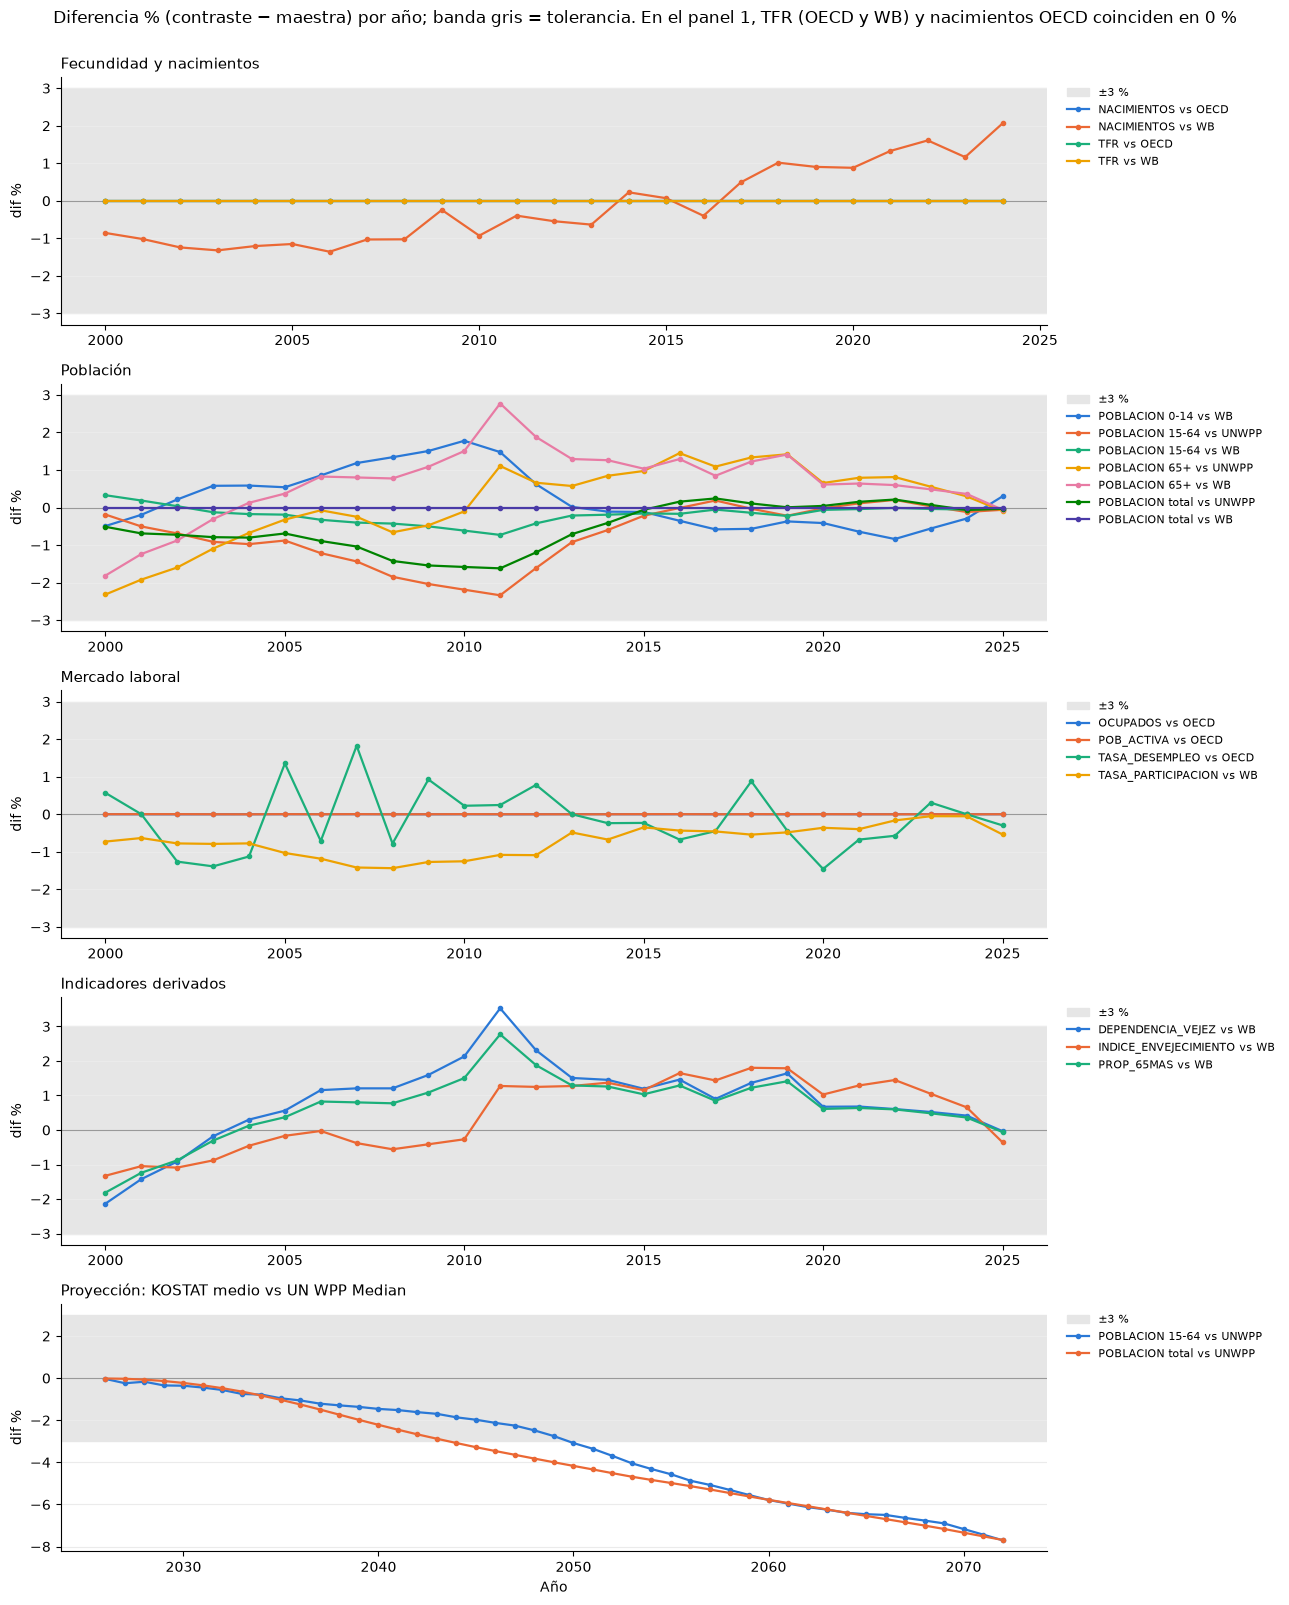

In [7]:
BLOQUES = {"Fecundidad y nacimientos": ("historico", ["TFR", "NACIMIENTOS"]),
           "Población": ("historico", ["POBLACION"]),
           "Mercado laboral": ("historico", ["POB_ACTIVA", "OCUPADOS", "TASA_PARTICIPACION", "TASA_DESEMPLEO"]),
           "Indicadores derivados": ("historico", ["DEPENDENCIA_VEJEZ", "INDICE_ENVEJECIMIENTO", "PROP_65MAS"]),
           "Proyección: KOSTAT medio vs UN WPP Median": ("proyeccion", ["POBLACION"])}
PALETA = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
fig, axes = plt.subplots(len(BLOQUES), 1, figsize=(13, 16))
for ax, (titulo, (nivel, inds)) in zip(axes, BLOQUES.items()):
    d = conc[(conc.nivel == nivel) & conc.cod_indicador.isin(inds)]
    ax.axhspan(-TOL, TOL, color="0.9", zorder=0, label=f"±{TOL:g} %")
    ax.axhline(0, color="0.6", lw=0.8)
    for i, ((ind, ge, fc), s) in enumerate(d.groupby(["cod_indicador", "grupo_edad", "fuente_contraste"])):
        etiqueta = f"{ind}{' total' if ind == 'POBLACION' and ge == 'TOTAL' else '' if ge == 'TOTAL' else ' ' + ge} vs {fc}"
        ax.plot(s.anio, s.dif_pct, lw=1.6, marker="o", ms=3, color=PALETA[i % len(PALETA)], label=etiqueta)
    ax.set_title(titulo, loc="left", fontsize=11)
    ax.set_ylabel("dif %")
    ax.grid(axis="y", color="0.92")
    ax.spines[["top", "right"]].set_visible(False)
    ax.legend(fontsize=8, frameon=False, loc="upper left", bbox_to_anchor=(1.01, 1))
axes[-1].set_xlabel("Año")
fig.suptitle("Diferencia % (contraste − maestra) por año; banda gris = tolerancia. "
             "En el panel 1, TFR (OECD y WB) y nacimientos OECD coinciden en 0 %", y=1.0)
fig.tight_layout()
plt.show()

## 5. Desvíos fuera de ±3 %

In [8]:
fuera = conc[conc.dif_pct.abs() > TOL]
(fuera.groupby(["nivel", "cod_indicador", "grupo_edad", "fuente_contraste"])
      .agg(pares_fuera=("anio", "size"), anios=("anio", lambda a: f"{a.min()}-{a.max()}"),
           dif_min=("dif_pct", "min"), dif_max=("dif_pct", "max")))

pares_fuera  \
nivel      cod_indicador     grupo_edad fuente_contraste                
historico  DEPENDENCIA_VEJEZ TOTAL      WB                          1   
proyeccion POBLACION         15-64      UNWPP                      23   
                             TOTAL      UNWPP                      29   

                                                              anios  dif_min  \
nivel      cod_indicador     grupo_edad fuente_contraste                       
historico  DEPENDENCIA_VEJEZ TOTAL      WB                2011-2011     3.53   
proyeccion POBLACION         15-64      UNWPP             2050-2072    -7.70   
                             TOTAL      UNWPP             2044-2072    -7.69   

                                                          dif_max  
nivel      cod_indicador     grupo_edad fuente_contraste           
historico  DEPENDENCIA_VEJEZ TOTAL      WB                   3.53  
proyeccion POBLACION         15-64      UNWPP               -3.08  
                             TOTAL      UNWPP               -3.08

In [9]:
# Evidencia para explicar los desvíos: dependencia 2011 (componentes vs WB) y proyección por grupo de edad
d11 = conc.query("fuente_contraste == 'WB' and anio in [2010, 2011, 2012] and "
                 "(cod_indicador == 'DEPENDENCIA_VEJEZ' or grupo_edad in ['15-64', '65+'])")
print("Dif % WB vs KOSIS:\n", d11.pivot_table(index=["cod_indicador", "grupo_edad"], columns="anio", values="dif_pct").round(2))
print("Crecimiento anual de la pob 65+ KOSIS (miles):", (agr.set_index("anio")["65+"].diff() / 1000).loc[2009:2013].round(0).to_dict())
proy = pd.DataFrame({g: pf.dif_pct(agr.set_index("anio")[g], un_agr.set_index("anio")[g]) for g in ["0-14", "15-64", "65+", "TOTAL"]})
proy.loc[[2030, 2040, 2050, 2060, 2072]].round(2)

Dif % WB vs KOSIS:
 anio                          2010  2011  2012
cod_indicador     grupo_edad                  
DEPENDENCIA_VEJEZ TOTAL       2.13  3.53  2.31
POBLACION         15-64      -0.61 -0.73 -0.42
                  65+         1.50  2.77  1.88
Crecimiento anual de la pob 65+ KOSIS (miles): {2009: 188.0, 2010: 189.0, 2011: 149.0, 2012: 252.0, 2013: 256.0}


,0-14,15-64,65+,TOTAL
anio,,,,
2030,3.79,-0.36,-1.17,-0.23
2040,-2.40,-1.46,-3.46,-2.22
2050,-5.79,-3.08,-5.25,-4.17
2060,0.69,-5.79,-6.78,-5.78
2072,4.07,-7.70,-9.29,-7.69


**Explicación de cada par que sale de ±3 %** (la maestra no se modifica en ningún caso):

- **DEPENDENCIA_VEJEZ vs WB, 2011 (+3,53 %)** es el único desvío histórico. Por separado, los componentes sí cumplen: 65+ da +2,77 % y 15-64 da −0,73 %. En el cociente, en cambio, las dos diferencias se suman. El origen es un escalón de cohorte en KOSIS: la población de 65+ crece solo 149 mil en 2011, frente a 189 mil en 2010 y 252 mil en 2012. La serie de WB, que es una estimación modelada de la estructura por edad, lo suaviza. Es una diferencia de método y no un error de carga, así que se documenta.
- **POBLACIÓN total (2044-2072) y 15-64 (2050-2072), KOSTAT medio vs UN WPP Median (hasta −7,7 %)**: la brecha crece con el horizonte de proyección. En 2072, UN WPP proyecta un 9,3 % menos de 65+, un 7,7 % menos de 15-64 y un 4,1 % más de 0-14. Esto refleja supuestos distintos de mortalidad, migración y fecundidad, además de ediciones distintas (KOSTAT 2022 vs WPP 2024). Es divergencia entre escenarios oficiales, no un problema de calidad, y se reporta fuera del KPI histórico.

## 6. Fuera del KPI: definiciones distintas
- **OECD `DEPEND_RATIO_OLD`** usa 65+/**20-64**. Se compara con nuestra dependencia (65+/15-64) y con la versión homologada 65+/20-64 calculada desde KOSIS.
- **PIB_HORA (OECD, maestra)** vs **WB `SL.GDP.PCAP.EM.KD`** (PIB por **ocupado**): no se comparan niveles, solo el crecimiento interanual.

In [10]:
od = lb.oecd("dependencia_vejez").query("REF_AREA == 'KOR' and SEX == '_T'").set_index("anio").valor
a = agr.set_index("anio").loc[list(HIST)]
dep = pd.DataFrame({"oecd_65_20_64": od,
                    "dif_vs_65_15_64": pf.dif_pct(a["65+"] / a["15-64"] * 100, od),
                    "dif_vs_65_20_64": pf.dif_pct(a["65+"] / a["20-64"] * 100, od)}).dropna()
for c in ["dif_vs_65_15_64", "dif_vs_65_20_64"]:
    r = pf.resumen_conciliacion(dep[c], TOL)
    print(f"OECD vs KOSIS {c[7:]}: {r['pares']} pares, {r['pct_dentro']:.1f} % dentro de ±{TOL:g} %, "
          f"dif media {dep[c].mean():.2f} %, máx |dif| {r['dif_max_abs_pct']:.2f} %")

pib = lb.oecd("productividad").set_index("anio").valor.sort_index()
crec = pd.DataFrame({"pib_hora_oecd": pib.pct_change() * 100,
                     "pib_ocupado_wb": wb["SL.GDP.PCAP.EM.KD"].pct_change() * 100}).dropna()
print(f"PIB_HORA vs PIB por ocupado: {len(crec)} años, correlación del crecimiento interanual = "
      f"{crec.corr().iloc[0, 1]:.2f}; crecimiento medio % {crec.mean().round(2).to_dict()}")

OECD vs KOSIS 65_15_64: 26 pares, 0.0 % dentro de ±3 %, dif media 9.25 %, máx |dif| 12.87 %
OECD vs KOSIS 65_20_64: 26 pares, 100.0 % dentro de ±3 %, dif media 0.00 %, máx |dif| 0.00 %
PIB_HORA vs PIB por ocupado: 25 años, correlación del crecimiento interanual = 0.83; crecimiento medio % {'pib_hora_oecd': 4.13, 'pib_ocupado_wb': 2.22}


| Indicador | Contraste | Años | Pares | % dentro ±3 % | Dif. media % | Máx. \|dif\| % |
|---|---|---|---|---|---|---|
| TFR | OECD | 2000-2024 | 25 | 100 | 0,00 | 0,00 |
| TFR | WB | 2000-2024 | 25 | 100 | 0,00 | 0,00 |
| NACIMIENTOS | OECD | 2000-2024 | 25 | 100 | 0,00 | 0,00 |
| NACIMIENTOS | WB (tasa bruta × pob) | 2000-2024 | 25 | 100 | −0,14 | 2,06 |
| POBLACIÓN total | WB / UN WPP | 2000-2025 | 26 / 26 | 100 / 100 | 0,00 / −0,53 | 0,00 / 1,62 |
| POBLACIÓN 0-14 | WB | 2000-2025 | 26 | 100 | 0,21 | 1,78 |
| POBLACIÓN 15-64 | WB / UN WPP | 2000-2025 | 26 / 26 | 100 / 100 | −0,18 / −0,71 | 0,73 / 2,34 |
| POBLACIÓN 65+ | WB / UN WPP | 2000-2025 | 26 / 26 | 100 / 100 | 0,65 / 0,11 | 2,77 / 2,32 |
| POB_ACTIVA | OECD | 2000-2025 | 26 | 100 | 0,00 | 0,00 |
| OCUPADOS | OECD | 2000-2025 | 26 | 100 | 0,00 | 0,00 |
| TASA_DESEMPLEO | OECD | 2000-2025 | 26 | 100 | −0,12 | 1,82 |
| TASA_PARTICIPACION | WB (OIT) | 2000-2025 | 26 | 100 | −0,71 | 1,44 |
| DEPENDENCIA_VEJEZ | WB | 2000-2025 | 26 | 96,2 | 0,84 | 3,53 |
| INDICE_ENVEJECIMIENTO | WB | 2000-2025 | 26 | 100 | 0,44 | 1,80 |
| PROP_65MAS | WB | 2000-2025 | 26 | 100 | 0,65 | 2,77 |
| **KPI histórico (KR3)** | | | **464** | **99,8** | | |
| Proyección total / 15-64 | UN WPP Median | 2026-2072 | 47 / 47 | 38,3 / 51,1 | −3,79 / −3,39 | 7,69 / 7,70 |
| Histórico + proyección | | | 558 | 90,5 | | |

**Hallazgos**
- **Se cumple la meta ≥ 90 %.** 463 de 464 pares históricos comparables (99,8 %) quedan dentro de ±3 %. El único desvío (dependencia de vejez vs WB en 2011) está explicado y documentado.
- Si se incluyen las proyecciones, el resultado es 505/558 = 90,5 %, en el límite de la meta. Por eso conviene medir el KPI sobre el histórico y reportar la proyección como divergencia entre escenarios.
- **Con OECD (TFR, nacimientos, activos y ocupados) y con la población total del WB la diferencia es 0 %**, porque esas fuentes republican las cifras de KOSTAT. Confirman que la carga y las unidades están bien (miles → personas, `UNIT_MULT`), pero no son una verificación independiente.
- Los contrastes independientes (UN WPP, la estructura por edad del WB y los nacimientos del WB calculados desde una tasa bruta redondeada) quedan dentro de ±2,8 %. La participación del WB, que es un modelo de la OIT, sale sistemáticamente más baja: −0,71 % en promedio.
- En la tasa de desempleo, la diferencia de hasta 1,82 % equivale a ≤ 0,06 pp. Se debe al redondeo a un decimal de KOSIS frente al promedio sin redondear de OECD.
- Para 2025 no hay contraste de TFR ni de nacimientos (OECD y WB llegan hasta 2024). El dato de KOSIS de 2025 queda como `preliminar`.
- Fuera del KPI:
  - La dependencia de OECD (65+/20-64) coincide al 0,00 % con KOSIS cuando se homologa a 20-64. Contra nuestra definición (65+/15-64) difiere en +9,25 % en promedio, así que en gold no hay que mezclar las dos definiciones.
  - El crecimiento del PIB por hora (OECD) y el del PIB por ocupado (WB) tienen una correlación de 0,83, pero crecen en promedio 4,13 % y 2,22 % al año. Esa brecha corresponde a la caída de las horas por ocupado.
- **Limitación de fuente:** OECD no publica `LF_WAP` en `DF_SUMTAB` (confirmado en la API), así que la participación solo se contrasta con WB. Alternativa: derivarla por sexo como `EMP_WAP / (1 − UNE_LF/100)`.